# HOMEWORK WEEK 3

#### In this week, a classification model will be built based on the `converted` variable - has the client signed up to the platform or not.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score, accuracy_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv")

In [3]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


#### Data preparation

###### If there are missing values:
>###### For `categorical` features, replace them with `'NA'`
>###### For `numerical` features, replace with with `0.0`

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               4852 non-null   str    
 1   industry                  4760 non-null   str    
 2   employment_status         4806 non-null   str    
 3   location                  4792 non-null   str    
 4   annual_income             4631 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                4965 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 351.7 KB


In [5]:
df.isna().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [6]:
# Convert the classification target to 'bool' so it is excluded for numerical column
df['converted'] = df['converted'].astype('bool')

In [7]:
# Select columns for categorical and numerical features
categorical = df.select_dtypes(include=['object', 'string']).columns.to_list()
numerical = df.select_dtypes(include=['number']).columns.to_list()

In [8]:
# Check if any missing value
df[categorical].isna().sum()

lead_source          148
industry             240
employment_status    194
location             208
dtype: int64

In [9]:
df[numerical].isna().sum()

annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
dtype: int64

In [10]:
# Fill missing values as requested
df[categorical] = df[categorical].fillna("NA")
df[numerical] = df[numerical].fillna(0)

In [11]:
# Check if all missing values have been filled
df[categorical].isna().sum()

lead_source          0
industry             0
employment_status    0
location             0
dtype: int64

In [12]:
df[numerical].isna().sum()

annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
dtype: int64

## Question 1

#### What is the most frequent observation (mode) for the column `industry`?

In [13]:
df['industry'].value_counts()

industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64

In [14]:
df['industry'].mode()

0    technology
Name: industry, dtype: str

## Question 2

#### Create the `correlation matrix` for the numerical features in the dataset.
#### What are the ***TWO features*** that have the biggest `correlation`?

In [15]:
correlation_matrix = df[numerical].corr()

correlation_matrix

,annual_income,number_of_courses_viewed,interaction_count,lead_score
annual_income,1.000000,0.161300,0.122842,0.229496
number_of_courses_viewed,0.161300,1.000000,0.721609,0.757204
interaction_count,0.122842,0.721609,1.000000,0.915746
lead_score,0.229496,0.757204,0.915746,1.000000


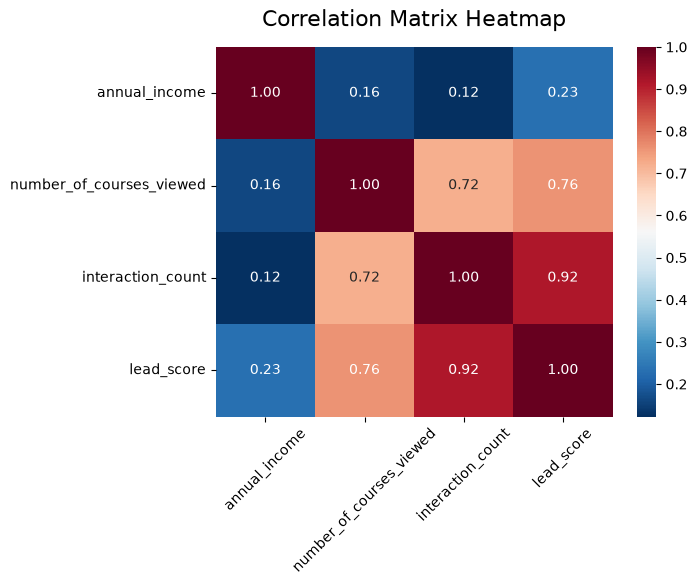

In [16]:
sns.heatmap(
    correlation_matrix,
    cmap='RdBu_r', 
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix Heatmap", fontsize=16, pad=15)
plt.xticks(rotation=45)

plt.show()

#### `interaction_count` and `lead_score` have the biggest correlation.

#### Split the data

In [17]:
# Split the data to train/val/test by 60%/20%/20%
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42) # 0.8 * 0.25 = 0.2

In [18]:
y_train = df_train['converted'].to_numpy()
y_val = df_val['converted'].to_numpy()
y_test = df_test['converted'].to_numpy()

In [19]:
try:
    del df_train['converted']
    del df_val['converted']
    del df_test['converted']

except:
    print("No data found.")

## Question 3

>##### 1. Calculate the mutual information score between `converted` and other `categorical` variables in the dataset.
>##### 2. Use the training set only.
>##### 3. Round the `scores` to 2 decimals.

#### Which of these variables has the biggest `mutual information score`?

In [20]:
# Function to compute mutual info score
def mutual_info_converted_score(series):
    
    return mutual_info_score(series, y_train)

In [21]:
mutual_info = df_train[categorical].apply(mutual_info_converted_score)
mutual_info.sort_values(ascending=False).round(2)

lead_source          0.03
employment_status    0.02
industry             0.00
location             0.00
dtype: float64

## Question 4

>##### 1. Now let's train a ***logistic regression***.
>##### 2. Include all categorical variables in the dataset using one-hot encoding.
>##### 3. Fit the model on the training dataset.
>##### 4. To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
>#####    `model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)`
>##### 5. Calculate the `accuracy` on the validation dataset and round it to 2 decimal digits.

#### What `accuracy` did you get?

In [22]:
# Convert python dict to a numeric array
dv = DictVectorizer(sparse=False)

# Using [categorical + numerical] explicitly to avoid inclusion of target column
# Use df_train only also works if done properly
train_dict = df_train[categorical + numerical].to_dict(orient='records')

X_train = dv.fit_transform(train_dict)

X_train.shape

(3000, 28)

In [ ]:
# Observe all the features used
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=retail',
       'industry=technology', 'interaction_count', 'lead_score',
       'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=europe',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [24]:
# Transform the validation dataset
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

X_val.shape

(1000, 28)

In [25]:
# Train a Logistic Regression model
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [26]:
# Calculate the soft prediction (probability)
y_pred = model.predict_proba(X_val)[:, 1]
baseline_score = accuracy_score(y_val, y_pred >= 0.5)

round(baseline_score, 2)

0.65

#### Extra

##### I will consider two more models for accuracy score comparison.
>##### 1. ***One Hot Encoder*** model using sklearn library.
>##### 2. ***One Hot Encoder*** and ***Scaling*** model using sklearn library.

In [27]:
# One hot encoder model
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False), categorical),
    ],
    remainder='passthrough'
)

In [28]:
# Use 'preprocessor' instead of 'dv'
X_train_ohe = preprocessor.fit_transform(df_train)

preprocessor.get_feature_names_out()

array(['cat__lead_source_NA', 'cat__lead_source_events',
       'cat__lead_source_organic_search', 'cat__lead_source_paid_ads',
       'cat__lead_source_referral', 'cat__lead_source_social_media',
       'cat__industry_NA', 'cat__industry_education',
       'cat__industry_finance', 'cat__industry_healthcare',
       'cat__industry_manufacturing', 'cat__industry_retail',
       'cat__industry_technology', 'cat__employment_status_NA',
       'cat__employment_status_employed',
       'cat__employment_status_self_employed',
       'cat__employment_status_student',
       'cat__employment_status_unemployed', 'cat__location_NA',
       'cat__location_africa', 'cat__location_asia',
       'cat__location_europe', 'cat__location_north_america',
       'cat__location_south_america', 'remainder__annual_income',
       'remainder__number_of_courses_viewed',
       'remainder__interaction_count', 'remainder__lead_score'],
      dtype=object)

In [29]:
X_val_ohe = preprocessor.transform(df_val)

model.fit(X_train_ohe, y_train)

y_pred_ohe = model.predict_proba(X_val_ohe)[:, 1]
ohe_score = accuracy_score(y_val, y_pred_ohe >= 0.5)

ohe_score

0.645

In [30]:
# One hot encoder and Scaling model
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False), categorical),
        ('num', StandardScaler(), numerical)
    ],
    remainder='passthrough'
)

In [31]:
X_train_ohe_scaled = preprocessor.fit_transform(df_train)

preprocessor.get_feature_names_out()

array(['cat__lead_source_NA', 'cat__lead_source_events',
       'cat__lead_source_organic_search', 'cat__lead_source_paid_ads',
       'cat__lead_source_referral', 'cat__lead_source_social_media',
       'cat__industry_NA', 'cat__industry_education',
       'cat__industry_finance', 'cat__industry_healthcare',
       'cat__industry_manufacturing', 'cat__industry_retail',
       'cat__industry_technology', 'cat__employment_status_NA',
       'cat__employment_status_employed',
       'cat__employment_status_self_employed',
       'cat__employment_status_student',
       'cat__employment_status_unemployed', 'cat__location_NA',
       'cat__location_africa', 'cat__location_asia',
       'cat__location_europe', 'cat__location_north_america',
       'cat__location_south_america', 'num__annual_income',
       'num__number_of_courses_viewed', 'num__interaction_count',
       'num__lead_score'], dtype=object)

In [32]:
X_val_ohe_scaled = preprocessor.transform(df_val)

model.fit(X_train_ohe_scaled, y_train)

y_pred_ohe_scaled = model.predict_proba(X_val_ohe_scaled)[:, 1]
ohe_scaled_score = accuracy_score(y_val, y_pred_ohe_scaled >= 0.5)

ohe_scaled_score

0.728

In [33]:
print(
    f'Base model score is {baseline_score}.\n'
    f'Ohe model score is {ohe_score}.\n'
    f'Ohe & scaled model score is {ohe_scaled_score}.\n'
)

Base model score is 0.645.
Ohe model score is 0.645.
Ohe & scaled model score is 0.728.



##### The base model and the model using one hot encoder module does not have significant difference in accuracy. 
##### However, the model using one hot encoder for categorial variables and scaling for numerical variables achieved the ***highest accuracy*** among these three models.

## Question 5

>##### 1. Find the least useful feature using the ***feature elimination*** technique.
>##### 2. Train a model using the same features and parameters as in Q4 (without rounding).
>##### 3. Now exclude each feature from this set and train a model without it. Record the `accuracy` for each model.
>##### 4. For each feature, calculate the `difference` between the `original accuracy` and the `accuracy` without the feature.

#### Which of following ***feature*** has the smallest ***difference***?

In [34]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)

# Function to calculate accuracy score with exclusion of one feature at a time
# And compare each score with the base model score
def each_feature_accuracy(df_train, df_val, model, baseline_score):

    feature_scores = []
    
    for col in categorical + numerical:
        df_train_reduced = df_train.copy()
        df_train_reduced = df_train_reduced.drop(columns=col)
        
        train_dict = df_train_reduced.to_dict(orient='records')
        X_train = dv.fit_transform(train_dict)

        df_val_reduced = df_val.copy()
        df_val_reduced = df_val_reduced.drop(columns=col)
        
        val_dict = df_val_reduced.to_dict(orient='records')
        X_val = dv.transform(val_dict)

        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_val)[:, 1]
        score = accuracy_score(y_val, y_pred >= 0.5)

        score_diff = abs(baseline_score - score)
        
        feature_scores.append((col, score, score_diff))

    return feature_scores


In [35]:
feature_scores = each_feature_accuracy(df_train, df_val, model, baseline_score)

In [36]:
# Sort by the score difference, lowest to highest
feature_scores.sort(key=lambda x:x[2])

for col, score, score_diff in feature_scores:
            
    print(
        f'Removing "{col}", \n'
        f'\tThe accuracy score is {score}, \n'
        f'\tThe difference is {score_diff:.3f}.\n'
    )
        

Removing "industry", 
	The accuracy score is 0.645, 
	The difference is 0.000.

Removing "employment_status", 
	The accuracy score is 0.645, 
	The difference is 0.000.

Removing "location", 
	The accuracy score is 0.645, 
	The difference is 0.000.

Removing "lead_score", 
	The accuracy score is 0.644, 
	The difference is 0.001.

Removing "number_of_courses_viewed", 
	The accuracy score is 0.643, 
	The difference is 0.002.

Removing "lead_source", 
	The accuracy score is 0.642, 
	The difference is 0.003.

Removing "interaction_count", 
	The accuracy score is 0.601, 
	The difference is 0.044.

Removing "annual_income", 
	The accuracy score is 0.724, 
	The difference is 0.079.



## Question 6

>##### 1. Now let's train a ***regularized logistic regression***.
>##### 2. Try the following values of the parameter `C`: `[0.000001, 0.00001, 0.0001, 0.001]`.
>##### 3. Train models using all the features as in Q4.
>##### 4. Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

#### Which of these `C` leads to the ***BEST accuracy*** on the validation set?

In [37]:
# Rerun to avoid any wrong cache data
train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [38]:
C = [0.000001, 0.00001, 0.0001, 0.001]
c_scores = []

for c in C:
    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]
    score = accuracy_score(y_val, y_pred >= 0.5)
    
    c_scores.append((c, score))
    

In [39]:
# Sort by the accuracy score, highest to lowest
c_scores.sort(key=lambda x:x[1], reverse=True)

for c, score in c_scores:
    print(f'When C = {c:8f}, accuracy score is {score}.')

When C = 0.001000, accuracy score is 0.645.
When C = 0.000100, accuracy score is 0.613.
When C = 0.000001, accuracy score is 0.598.
When C = 0.000010, accuracy score is 0.598.
